In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, f1_score, accuracy_score

from lightgbm import LGBMRegressor
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv(r"../data/raw/Spotify_Dataset_V3_All_Clusters_v2.csv")

df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date_parsed'])

print(f"Loaded {len(df)} rows.")
df.head(3)

Loaded 651936 rows.


,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Temporal_Cluster_Name,Performance_Cluster,Performance_Cluster_Name,Collab_Cluster_ID,Collab_Cluster_Name,Evo_Cluster_ID,Evo_Cluster_Name,Geo_Cluster_ID,Geo_Cluster_Name,Date_parsed
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,...,Spring - Friday Fresh,1,Strong Performer,1,Hub Artist,2,Mainstream Follower,0,Local Hero,2023-05-29
1,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",29/05/2023,0.668,0.758,-5176.0,0.033,0.483,0.000,...,Spring - Friday Fresh,1,Strong Performer,1,Hub Artist,2,Mainstream Follower,0,Local Hero,2023-05-29
2,2,WHERE SHE GOES,Bad Bunny,29/05/2023,0.652,0.800,-4019.0,0.061,0.143,0.629,...,Spring - Friday Fresh,1,Strong Performer,1,Hub Artist,0,Trend Setter,0,Local Hero,2023-05-29


In [2]:

df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date_parsed'])
df['year_week'] = df['Date_parsed'].dt.isocalendar().year.astype(str) + '-W' + \
                  df['Date_parsed'].dt.isocalendar().week.astype(str)

agg = df.groupby('id').agg(
    weeks_in_top200=('year_week', 'nunique'),
    first_chart_date=('Date_parsed', 'min'),
    initial_rank=('Rank', 'min'),
    max_rank=('Rank', 'max')
).reset_index()

agg['song_year'] = agg['first_chart_date'].dt.year
agg['song_month'] = agg['first_chart_date'].dt.month
agg['song_season'] = agg['song_month'] % 12 // 3 + 1
agg['rank_slope'] = (agg['max_rank'] - agg['initial_rank']) / agg['weeks_in_top200']
agg['rank_slope'] = agg['rank_slope'].replace([np.inf, -np.inf], 0).fillna(0)

cluster_cols = ['Sonic_Cluster_Label', 'Artist_Tier_Label', 'Temporal_Cluster_Name',
             'Performance_Cluster_Name', 'Collab_Cluster_Name', 'Geo_Cluster_Name', 
             'Evo_Cluster_Name']
audio_cols = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 
                'Acousticness', 'Instrumentalness', 'Valence', 'Points (Total)']

static_data = df.groupby('id').first().reset_index()
agg = agg.merge(static_data[['id'] + cluster_cols + audio_cols + ['Artists']], on='id')

agg['artist_count'] = agg['Artists'].fillna('').apply(lambda x: len(str(x).split(',')))
agg['superstar'] = (agg['Artist_Tier_Label'] == 'Superstars').astype(int)

agg = agg.dropna(subset=['weeks_in_top200'])
y_reg = np.log1p(agg['weeks_in_top200'])

In [3]:
raw_feats = audio_cols + ['song_year', 'song_month', 'song_season', 'rank_slope', 'artist_count', 'superstar']
cluster_feats = cluster_cols

experiments = {
    "Test 1: Raw Features Only": {'num': raw_feats, 'cat': []},
    "Test 2: Cluster Features Only": {'num': [], 'cat': cluster_feats},
    "Test 3: Combined (Raw + Clusters)": {'num': raw_feats, 'cat': cluster_feats}
}

dates = agg['first_chart_date']
cutoff = np.percentile(dates, 80)
train_idx = dates <= cutoff
test_idx = dates > cutoff

ablation_results = []

for name, feats in experiments.items():
    transformers = []
    if feats['num']:
        num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
        transformers.append(('num', num_pipe, feats['num']))
    if feats['cat']:
        cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
        transformers.append(('cat', cat_pipe, feats['cat']))
        
    preprocessor = ColumnTransformer(transformers=transformers)
    
    model = Pipeline([
        ('prep', preprocessor),
        ('lgbm', LGBMRegressor(random_state=42, learning_rate=0.1, n_estimators=300, max_depth=12))
    ])
    
    X = agg[feats['num'] + feats['cat']]
    
    model.fit(X[train_idx], y_reg[train_idx])
    preds = model.predict(X[test_idx])
    
    r2 = r2_score(y_reg[test_idx], preds)
    
    ablation_results.append({'Model': name, 'R-Squared': r2*100})

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2177
[LightGBM] [Info] Number of data points in the train set: 7334, number of used features: 14
[LightGBM] [Info] Start training from score 1.634079
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 7334, number of used features: 34
[LightGBM] [Info] Start training from score 1.634079
[LightGBM] [Info] Auto-choosing

                            Model  R-Squared
Test 3: Combined (Raw + Clusters)      88.87
        Test 1: Raw Features Only      73.81
    Test 2: Cluster Features Only      35.69
Saved chart to ..\outputs\figures\regression_ablation_study_results.svg


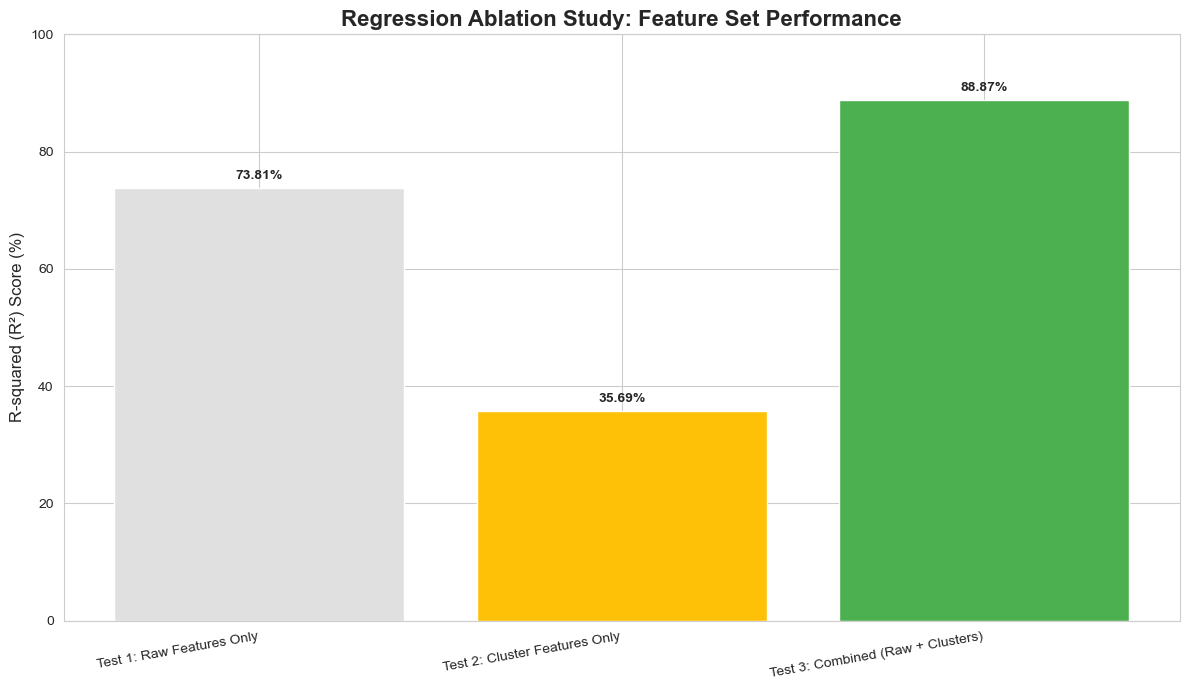

In [4]:
results_df = pd.DataFrame(ablation_results).sort_values('R-Squared', ascending=False)
print(results_df.to_string(index=False, float_format="%.2f"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

custom_colors = ['#E0E0E0', '#FFC107', '#4CAF50'] 

try:
    results_df = results_df.reindex(results_df['Model'].map({
        "Test 1: Raw Features Only": 0,
        "Test 2: Cluster Features Only": 1,
        "Test 3: Combined (Raw + Clusters)": 2
    }).sort_values().index)
except:
    pass

bars = plt.bar(results_df['Model'], results_df['R-Squared'], color=custom_colors)

plt.ylabel('R-squared (R²) Score (%)', fontsize=12)
plt.title('Regression Ablation Study: Feature Set Performance', fontsize=16, fontweight='bold')
plt.ylim(0, 100)
plt.xticks(rotation=10, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(r"..\outputs\figures\regression_ablation_study_results.svg", dpi=300)
print(r"Saved chart to ..\outputs\figures\regression_ablation_study_results.svg")
plt.show()

In [5]:

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

song_stats = df.groupby('id').size().reset_index(name='weeks')
song_stats['is_hit'] = (song_stats['weeks'] >= 8).astype(int)

audio_feats = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence']
cluster_feats_clf = ['Sonic_Cluster', 'Artist_Tier', 'Temporal_Cluster', 'Performance_Cluster', 'Geo_Cluster_ID', 'Collab_Cluster_ID', 'Evo_Cluster_ID']

features_df = df.sort_values('Date').groupby('id').first().reset_index()
clf_data = features_df.merge(song_stats[['id', 'is_hit']], on='id')

y_clf = clf_data['is_hit']

In [6]:
tests = {
    "Test 1: Raw Audio Only (Baseline)": audio_feats,
    "Test 2: Raw Audio + Performance_Cluster": audio_feats + ['Performance_Cluster'],
    "Test 3: Raw Audio + All Clusters (Full Model)": list(set(audio_feats + cluster_feats_clf))
}

ablation_results = []

for label, cols in tests.items():
    X = clf_data[cols].copy()
    X = pd.get_dummies(X, drop_first=True) 
    
    X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
    
    model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    f1 = f1_score(y_test, preds)
    acc = accuracy_score(y_test, preds)
    
    ablation_results.append({'Model': label, 'F1-Score': f1*100, 'Accuracy': acc*100})

                                        Model  F1-Score  Accuracy
Test 3: Raw Audio + All Clusters (Full Model)     79.72     77.96
      Test 2: Raw Audio + Performance_Cluster     76.85     75.01
            Test 1: Raw Audio Only (Baseline)     66.30     59.41
Saved chart to ..\outputs\figures\binary_ablation_study_results.svg


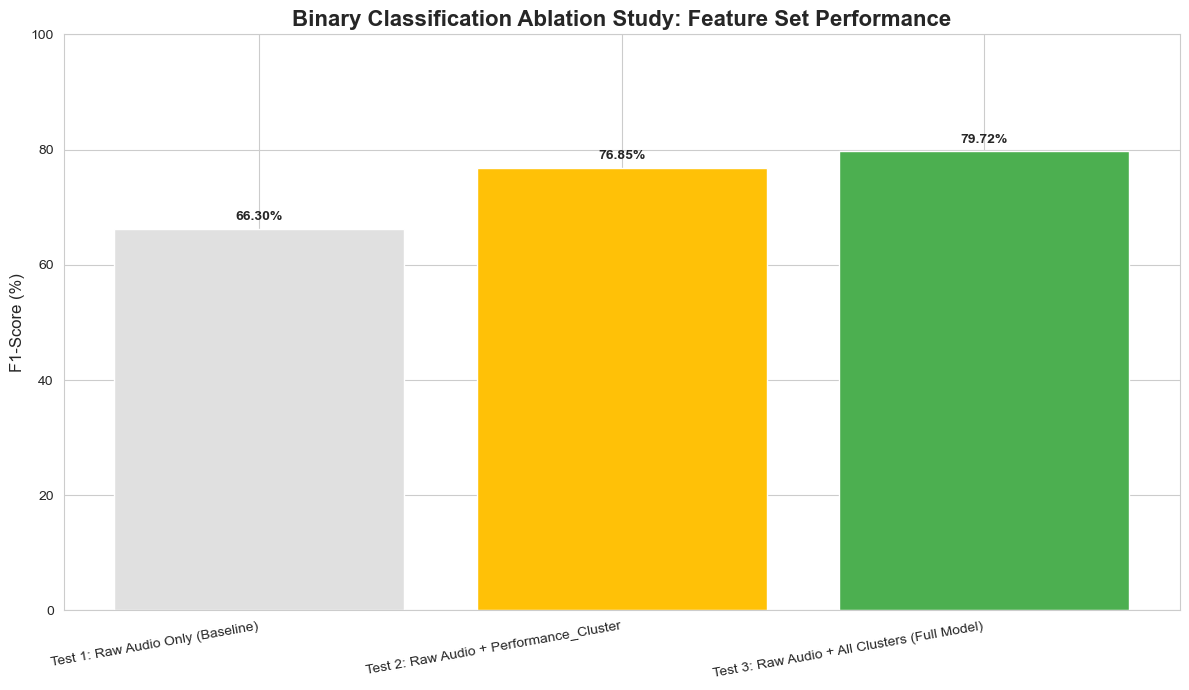

In [7]:
results_df = pd.DataFrame(ablation_results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False, float_format="%.2f"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

custom_colors = ['#E0E0E0', '#FFC107', '#4CAF50']

try:
    results_df = results_df.reindex(results_df['Model'].map({
        "Test 1: Raw Audio Only (Baseline)": 0,
        "Test 2: Raw Audio + Performance_Cluster": 1,
        "Test 3: Raw Audio + All Clusters (Full Model)": 2
    }).sort_values().index)
except:
    pass

bars = plt.bar(results_df['Model'], results_df['F1-Score'], color=custom_colors)

plt.ylabel('F1-Score (%)', fontsize=12)
plt.title('Binary Classification Ablation Study: Feature Set Performance', fontsize=16, fontweight='bold')
plt.ylim(0, 100) 
plt.xticks(rotation=10, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(r"..\outputs\figures\binary_ablation_study_results.svg", dpi=300)
print(r"Saved chart to ..\outputs\figures\binary_ablation_study_results.svg")
plt.show()

In [8]:

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

song_weeks = df.groupby('id').agg({'Date': 'count'}).reset_index()
song_weeks.columns = ['id', 'Weeks_In_Charts']

def categorize_success_3class(weeks):
    if weeks < 2:
        return 'Flop'
    elif weeks < 20:
        return 'Moderate Hit'
    else:
        return 'Long-Term Hit'

song_weeks['Success_Category'] = song_weeks['Weeks_In_Charts'].apply(categorize_success_3class)
print("Target variable created successfully.")

Target variable created successfully.


In [9]:
song_features = df.sort_values('Date').groupby('id').first().reset_index()

features_raw_audio = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness', 
    'Acousticness', 'Instrumentalness', 'Valence'
]

features_all_clusters = [
    'Sonic_Cluster', 'Artist_Tier', 'Temporal_Cluster',
    'Performance_Cluster', 'Geo_Cluster_ID', 'Collab_Cluster_ID', 'Evo_Cluster_ID'
]

features_test_1 = features_raw_audio
features_test_2 = features_raw_audio + ['Performance_Cluster']
features_test_3 = sorted(list(set(features_raw_audio + features_all_clusters)))

all_features_needed = sorted(list(set(features_test_1 + features_test_2 + features_test_3)))
features_to_keep = ['id'] + all_features_needed

song_features_selected = song_features[features_to_keep]

final_data = song_features_selected.merge(
    song_weeks[['id', 'Success_Category']], 
    on='id', 
    how='inner'
)
final_data = final_data.dropna(subset=['Success_Category'] + all_features_needed)
print(f"Feature master table created with {len(final_data)} unique songs.")

Feature master table created with 9161 unique songs.


In [10]:
feature_sets_to_test = {
    "Test 1: Raw Audio Only (Baseline)": features_test_1,
    "Test 2: Raw Audio + Performance_Cluster": features_test_2,
    "Test 3: Raw Audio + All Clusters (Full Model)": features_test_3
}

y = final_data['Success_Category']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

ablation_results = []

In [11]:
for set_name, set_features in feature_sets_to_test.items():
    print(f"\n--- Testing Model: {set_name} ---")
    print(f"   Features ({len(set_features)}): {', '.join(set_features)}")
    
    X = final_data[set_features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_encoded 
    )
    
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    )
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, average='weighted') * 100
    acc = accuracy_score(y_test, y_pred) * 100
    
    print(f"   Completed in: {train_time:.2f}s")
    print(f"   Test F1-Score: {f1:.2f}%")
    
    ablation_results.append({
        'Model': set_name,
        'F1-Score': f1,
        'Accuracy': acc,
        'Num_Features': len(set_features)
    })


--- Testing Model: Test 1: Raw Audio Only (Baseline) ---
   Features (7): Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Valence
   Completed in: 5.20s
   Test F1-Score: 43.57%

--- Testing Model: Test 2: Raw Audio + Performance_Cluster ---
   Features (8): Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Valence, Performance_Cluster
   Completed in: 5.41s
   Test F1-Score: 55.18%

--- Testing Model: Test 3: Raw Audio + All Clusters (Full Model) ---
   Features (14): Acousticness, Artist_Tier, Collab_Cluster_ID, Danceability, Energy, Evo_Cluster_ID, Geo_Cluster_ID, Instrumentalness, Loudness, Performance_Cluster, Sonic_Cluster, Speechiness, Temporal_Cluster, Valence
   Completed in: 5.99s
   Test F1-Score: 57.95%


                                        Model  F1-Score  Accuracy  Num_Features
Test 3: Raw Audio + All Clusters (Full Model)     57.95     58.10            14
      Test 2: Raw Audio + Performance_Cluster     55.18     55.32             8
            Test 1: Raw Audio Only (Baseline)     43.57     46.26             7

Saved chart to 'granular_ablation_study_results.png'


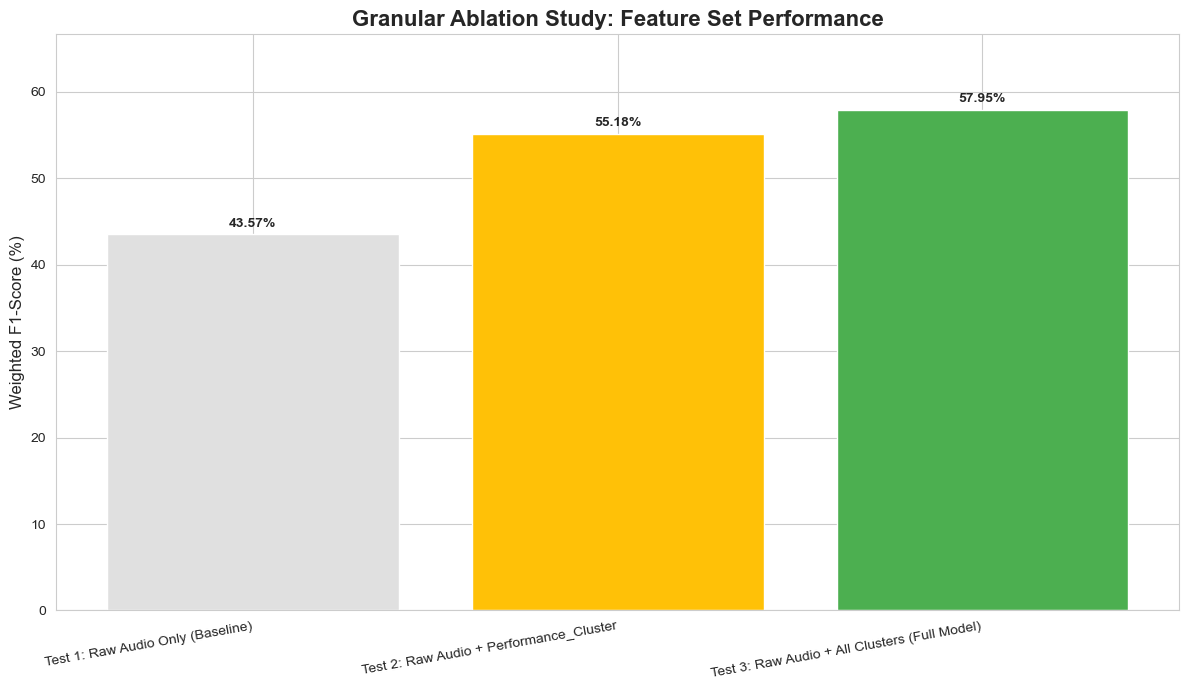

In [12]:
results_df = pd.DataFrame(ablation_results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False, float_format="%.2f"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

custom_colors = ['#E0E0E0', '#FFC107', '#4CAF50']

try:
    results_df = results_df.reindex(results_df['Model'].map({
        "Test 1: Raw Audio Only (Baseline)": 0,
        "Test 2: Raw Audio + Performance_Cluster": 1,
        "Test 3: Raw Audio + All Clusters (Full Model)": 2
    }).sort_values().index)
except:
    pass

bars = plt.bar(results_df['Model'], results_df['F1-Score'], color=custom_colors)

plt.ylabel('Weighted F1-Score (%)', fontsize=12)
plt.title('Granular Ablation Study: Feature Set Performance', fontsize=16, fontweight='bold')
plt.ylim(0, max(results_df['F1-Score']) * 1.15)
plt.xticks(rotation=10, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
             
plt.tight_layout()
plt.savefig(r"..\outputs\figures\granular_ablation_study_results.png", dpi=300)
print("\nSaved chart to 'granular_ablation_study_results.png'")
plt.show()